In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
pd.set_option('mode.chained_assignment', None)

In [3]:
df = pd.read_parquet("../../novus/matchingnemo/scratch/ampnet_data/Portland/", engine = "pyarrow")

In [4]:
# safegraph data coverage (safegraph match / total FEMA buildings)
len(df[df['t'].notna()])/len(df['t'])

0.8196768408626384

In [5]:
dat = df.dropna()
dat['sq_q'] = pd.qcut(dat['sqmeters'], q=4, labels=[1, 2, 3, 4])

In [6]:
# Check for bug in Safegraph and FEMA data prep. No duplicates = good
dat[dat.duplicated(subset = ['build_id', 'date_range_start', 't'], keep = False)].sort_values(by = ['date_range_start', 'build_id', 't'])

,build_id,t,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,visits,sq_q


In [7]:
# Hold out 10% of buildings
builds = dat["build_id"].unique()
rng = np.random.default_rng()
builds = rng.choice(builds, len(builds) // 10)

mask = dat["build_id"].isin(builds)
tr = dat[~mask]
test = dat[mask]

In [8]:
group = (
    tr.dropna()
    .groupby(['t', 'sq_q', 'prim_occ'], observed=False)
    .agg(visits=('visits', 'mean'))
    .reset_index()
)

# temporal mean: average just by hour of week and building type
# used to fill the table when [t, sq_q, prim_occ] combo doesn't exist in training data?
temporal_mean = (
    tr.groupby(['t', 'prim_occ'])['visits']
      .mean()
      .rename('fallback')
      .reset_index())

group = group.merge(
    temporal_mean,
    on=['t', 'prim_occ'],
    how='left')

group['visits'] = group['visits'].fillna(group['fallback'])
group = group.drop('fallback', axis = 1)

group


,t,sq_q,prim_occ,visits
0,0.0,1,Agriculture,0.000000
1,0.0,1,Aviation,33.685897
2,0.0,1,Colleges/Universities,0.038462
3,0.0,1,Community Center,0.025641
4,0.0,1,Emergency Response,0.000000
...,...,...,...,...
15451,167.0,4,Religious,0.074411
15452,167.0,4,Retail Trade,0.242602
15453,167.0,4,Theaters,0.028846
15454,167.0,4,Unclassified,0.118156


In [19]:
group.pivot(index=["t", "sq_q"], columns="prim_occ", values="visits").reset_index().drop('sq_q', axis = 1).groupby('t').agg('mean')

prim_occ,Agriculture,Aviation,Colleges/Universities,Community Center,Emergency Response,Energy Control Monitoring,Entertainment and Recreation,General Services,Hospital,Indoor Arena,...,Other Educational Buildings,Parking,Personal and Repair Services,Pre-K - 12 Schools,Professional/Technical Services,Religious,Retail Trade,Theaters,Unclassified,Wholesale Trade
t,,,,,,,,,,,,,,,,,,,,,
0.0,0.000000,33.685897,0.118139,0.039389,0.040202,0.346154,0.130968,0.083659,2.197802,0.615385,...,0.066140,0.090381,0.048423,0.053786,0.073905,0.046908,0.093821,0.022477,0.077118,0.088208
1.0,0.000000,12.576923,0.094911,0.029573,0.055330,0.269231,0.098050,0.056046,2.096154,0.442308,...,0.043410,0.077175,0.042507,0.053335,0.059634,0.036976,0.073990,0.037321,0.058579,0.071930
2.0,0.000000,11.788462,0.071048,0.024365,0.046898,0.192308,0.077541,0.063227,1.728022,0.211538,...,0.040981,0.066483,0.034455,0.033211,0.050813,0.027798,0.063170,0.007633,0.060146,0.056153
3.0,0.000000,31.480769,0.066508,0.035783,0.040838,0.211538,0.058433,0.094375,1.604396,0.240385,...,0.031281,0.096012,0.032337,0.027478,0.042109,0.020549,0.057077,0.012440,0.048955,0.043160
4.0,0.000000,78.967949,0.078193,0.075215,0.049119,0.288462,0.086046,0.130437,3.005495,0.298077,...,0.041067,0.139350,0.035836,0.031370,0.061544,0.020675,0.070683,0.000000,0.067061,0.066983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163.0,0.032787,75.929487,0.307980,0.376725,0.130166,2.576923,0.688563,0.180430,6.041209,29.346154,...,0.188582,0.359673,0.124287,0.163312,0.208596,0.150801,0.526202,0.173023,0.257119,0.111922
164.0,0.032787,81.814103,0.289627,0.262955,0.163797,2.000000,0.489666,0.126945,3.945055,12.932692,...,0.143484,0.239853,0.100870,0.158567,0.159933,0.114292,0.369935,0.151116,0.164441,0.114126
165.0,0.049180,84.307692,0.232660,0.143131,0.110595,1.250000,0.350982,0.127419,3.351648,6.692308,...,0.112768,0.258288,0.080559,0.114288,0.137738,0.092674,0.257340,0.178401,0.150642,0.097844


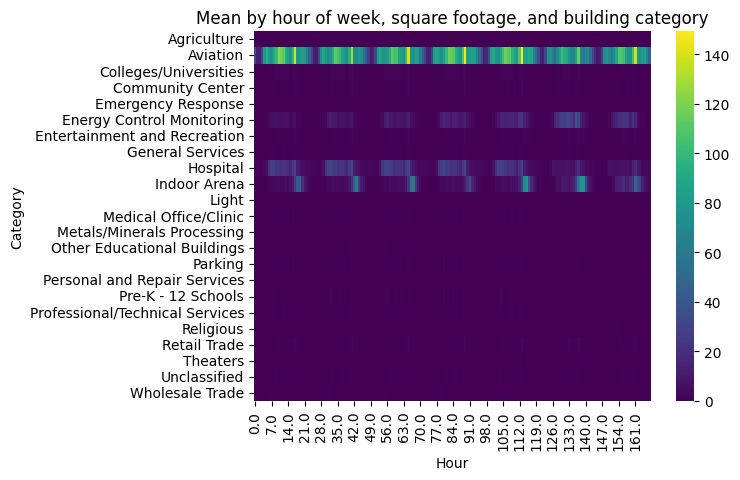

In [23]:
visits_data = group.pivot(index=["t", "sq_q"], columns="prim_occ", values="visits").reset_index().drop('sq_q', axis = 1).groupby('t').agg('mean').transpose()
sns.heatmap(visits_data, cmap="viridis", cbar=True)
# sns.heatmap(visits_data, cmap="viridis", cbar=True, vmax = 20)

plt.xlabel("Hour")
plt.ylabel("Category")
plt.title("Mean by hour of week, square footage, and building category")
plt.show()

In [12]:
test_pred = test.merge(
    group[['t', 'sq_q', 'prim_occ', 'visits']],
    on=['t', 'sq_q', 'prim_occ'],
    how='left',
    suffixes=('', '_pred')
)

In [13]:
test_pred

,build_id,t,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,visits,sq_q,visits_pred
0,13448,0.0,Commercial,Medical Office/Clinic,2120.914307,22829.308594,41067032005,{20d34138-2c19-44a0-9763-f35aa346de48},sg:0c3858121a9346b3ae3f04216e890031,2018-12-31 08:00:00,1.0,4,0.126781
1,13448,1.0,Commercial,Medical Office/Clinic,2120.914307,22829.308594,41067032005,{20d34138-2c19-44a0-9763-f35aa346de48},sg:0c3858121a9346b3ae3f04216e890031,2018-12-31 08:00:00,0.0,4,0.104701
2,13448,2.0,Commercial,Medical Office/Clinic,2120.914307,22829.308594,41067032005,{20d34138-2c19-44a0-9763-f35aa346de48},sg:0c3858121a9346b3ae3f04216e890031,2018-12-31 08:00:00,0.0,4,0.098291
3,13448,3.0,Commercial,Medical Office/Clinic,2120.914307,22829.308594,41067032005,{20d34138-2c19-44a0-9763-f35aa346de48},sg:0c3858121a9346b3ae3f04216e890031,2018-12-31 08:00:00,0.0,4,0.093305
4,13448,4.0,Commercial,Medical Office/Clinic,2120.914307,22829.308594,41067032005,{20d34138-2c19-44a0-9763-f35aa346de48},sg:0c3858121a9346b3ae3f04216e890031,2018-12-31 08:00:00,0.0,4,0.129630
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886611,8214501,163.0,Assembly,Religious,1002.429321,10790.048828,41051003802,{6a97eccc-04e9-4366-965c-be301c3cd1d1},sg:f76201b6d8414a0aa6007d0d7e033dfc,2019-02-25 08:00:00,0.0,3,0.136047
4886612,8214501,164.0,Assembly,Religious,1002.429321,10790.048828,41051003802,{6a97eccc-04e9-4366-965c-be301c3cd1d1},sg:f76201b6d8414a0aa6007d0d7e033dfc,2019-02-25 08:00:00,1.0,3,0.121939
4886613,8214501,165.0,Assembly,Religious,1002.429321,10790.048828,41051003802,{6a97eccc-04e9-4366-965c-be301c3cd1d1},sg:f76201b6d8414a0aa6007d0d7e033dfc,2019-02-25 08:00:00,0.0,3,0.092103
4886614,8214501,166.0,Assembly,Religious,1002.429321,10790.048828,41051003802,{6a97eccc-04e9-4366-965c-be301c3cd1d1},sg:f76201b6d8414a0aa6007d0d7e033dfc,2019-02-25 08:00:00,1.0,3,0.086752


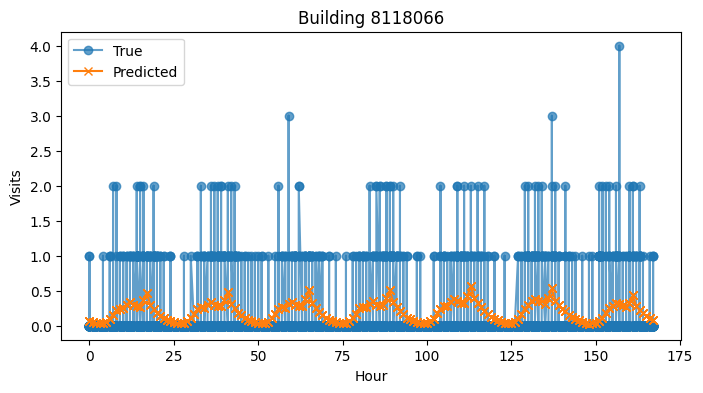

In [15]:
build = np.random.default_rng().choice(test_pred['build_id'].unique())

build_preds = (
    test_pred[test_pred['build_id'] == build]
    .sort_values('t')
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    build_preds['t'],
    build_preds['visits'],
    marker='o',
    alpha=0.7,
    label='True'
)

ax.plot(
    build_preds['t'],
    build_preds['visits_pred'],
    marker='x',
    label='Predicted'
)

ax.set(
    xlabel='Hour',
    ylabel='Visits',
    title=f"Building {build}"
)

ax.legend()
plt.show()